In [ ]:
# basic imports - the usual stuff
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# sklearn stuff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
from imblearn.over_sampling import SMOTE

# tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


#from pytorch_tabnet.tab_model import TabNetClassifier  # we'll replace this with tf version
#import tensorflow_addons as tfa

# shap for explainability
import shap

# misc
import os
import joblib


np.random.seed(42)
tf.random.set_seed(42)

print('TF version:', tf.__version__)
print('All imports done!')

TF version: 2.10.1
All imports done!


In [2]:
# load the dataset
df = pd.read_csv('../Dataset/churn_modelling.csv')

print('Shape:', df.shape)
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# quick look at the data types and missing values
print(df.info())
print('\nMissing values:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None

Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditSco

In [4]:
print(df.describe())

         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    5000.50000  1.569094e+07    650.528800     38.921800      5.012800   
std     2886.89568  7.193619e+04     96.653299     10.487806      2.892174   
min        1.00000  1.556570e+07    350.000000     18.000000      0.000000   
25%     2500.75000  1.562853e+07    584.000000     32.000000      3.000000   
50%     5000.50000  1.569074e+07    652.000000     37.000000      5.000000   
75%     7500.25000  1.575323e+07    718.000000     44.000000      7.000000   
max    10000.00000  1.581569e+07    850.000000     92.000000     10.000000   

             Balance  NumOfProducts    HasCrCard  IsActiveMember  \
count   10000.000000   10000.000000  10000.00000    10000.000000   
mean    76485.889288       1.530200      0.70550        0.515100   
std     62397.405202       0.581654      0.45584        0.499797   
min         0.000000     

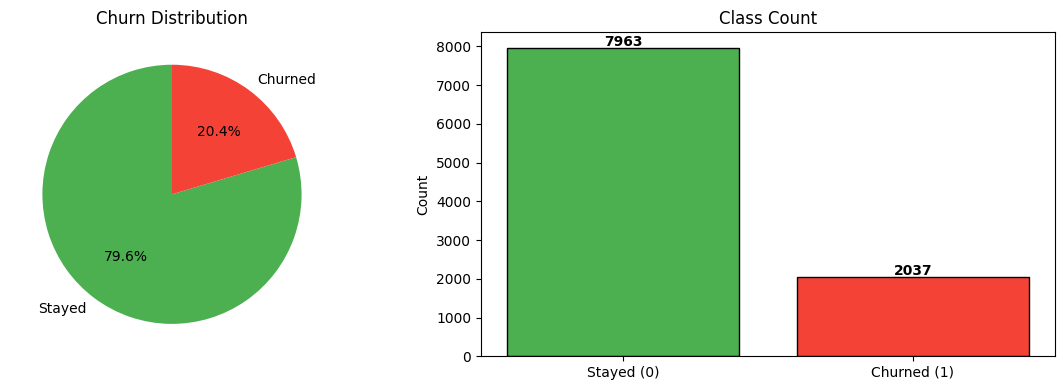

Class imbalance ratio: 3.91:1


In [5]:
# class distribution - checking for imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['Exited'].value_counts()
axes[0].pie(churn_counts, labels=['Stayed', 'Churned'], autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90)
axes[0].set_title('Churn Distribution')

axes[1].bar(['Stayed (0)', 'Churned (1)'], churn_counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='black')
axes[1].set_title('Class Count')
axes[1].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../Images/img1.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Class imbalance ratio: {churn_counts[0]/churn_counts[1]:.2f}:1')

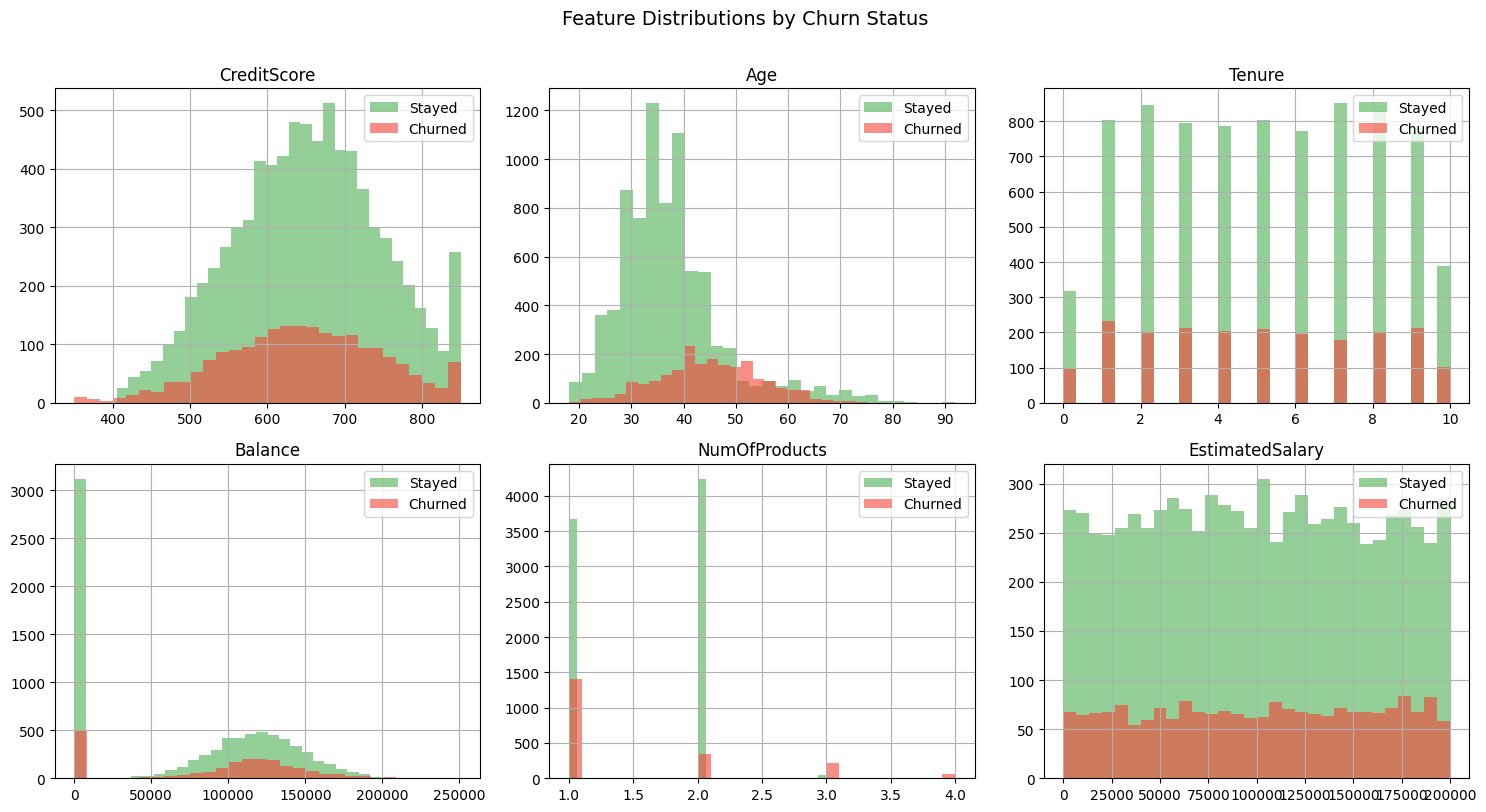

In [6]:
# distributions of numerical features
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
            'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df[df['Exited'] == 0][col].hist(ax=axes[i], alpha=0.6, color='#4CAF50',
                                     label='Stayed', bins=30)
    df[df['Exited'] == 1][col].hist(ax=axes[i], alpha=0.6, color='#F44336',
                                     label='Churned', bins=30)
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('Feature Distributions by Churn Status', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../Images/img1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

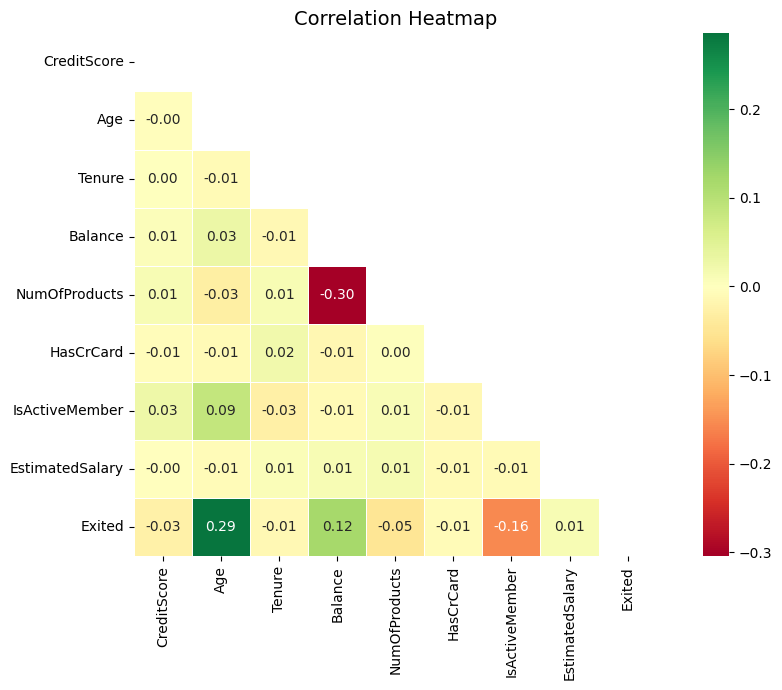

In [7]:
# correlation heatmap
plt.figure(figsize=(10, 7))
corr_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
             'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('../Images/img1_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

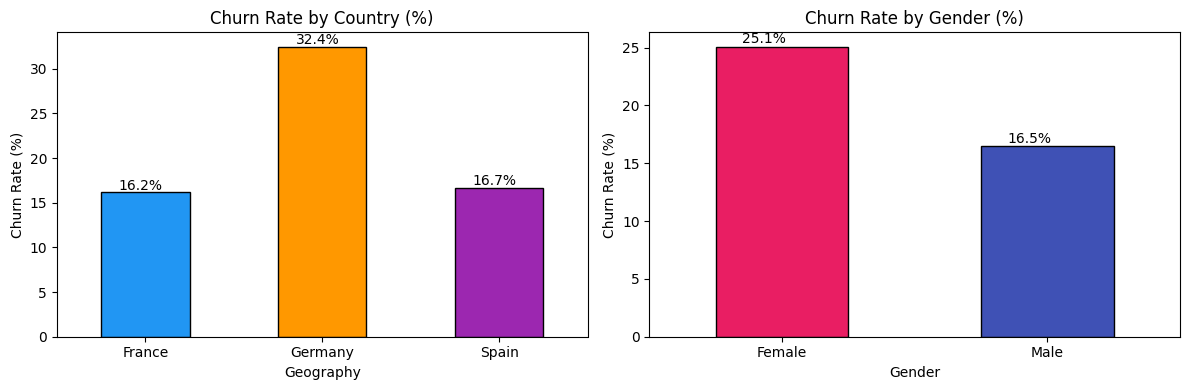

In [8]:
# churn by geography and gender
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_geo = df.groupby('Geography')['Exited'].mean() * 100
churn_geo.plot(kind='bar', ax=axes[0], color=['#2196F3', '#FF9800', '#9C27B0'],
               edgecolor='black', rot=0)
axes[0].set_title('Churn Rate by Country (%)')
axes[0].set_ylabel('Churn Rate (%)')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%', (p.get_x() + 0.1, p.get_height() + 0.3))

churn_gender = df.groupby('Gender')['Exited'].mean() * 100
churn_gender.plot(kind='bar', ax=axes[1], color=['#E91E63', '#3F51B5'],
                  edgecolor='black', rot=0)
axes[1].set_title('Churn Rate by Gender (%)')
axes[1].set_ylabel('Churn Rate (%)')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%', (p.get_x() + 0.1, p.get_height() + 0.3))

plt.tight_layout()
plt.savefig('../Images/img1_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# dropping unusefull column
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])


le = LabelEncoder()
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])  # Male=1, Female=0


df_clean = pd.get_dummies(df_clean, columns=['Geography'], drop_first=True)

print('Cleaned shape:', df_clean.shape)
print('Columns:', df_clean.columns.tolist())
df_clean.head()

Cleaned shape: (10000, 12)
Columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [ ]:

X = df_clean.drop('Exited', axis=1).values
y = df_clean['Exited'].values

feature_names = df_clean.drop('Exited', axis=1).columns.tolist()


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size: {X_train_sc.shape}, Test size: {X_test_sc.shape}')

Train size: (8000, 11), Test size: (2000, 11)


In [ ]:

unique, counts = np.unique(y_train, return_counts=True)
print('Before SMOTE:', dict(zip(unique, counts)))

imbalance_ratio = counts[0] / counts[1]
print(f'Imbalance ratio: {imbalance_ratio:.2f}')

if imbalance_ratio > 1.5:
    print('Applying SMOTE...')
    sm = SMOTE(random_state=42)
    X_train_sm, y_train_sm = sm.fit_resample(X_train_sc, y_train)
    unique2, counts2 = np.unique(y_train_sm, return_counts=True)
    print('After SMOTE:', dict(zip(unique2, counts2)))
else:
    X_train_sm, y_train_sm = X_train_sc, y_train
    print('No SMOTE needed')

Before SMOTE: {0: 6370, 1: 1630}
Imbalance ratio: 3.91
Applying SMOTE...
After SMOTE: {0: 6370, 1: 6370}


In [ ]:
# utility function to evaluate any model and plot results
def evaluate_model(model_name, y_true, y_pred_proba, y_pred=None):
    if y_pred is None:
        y_pred = (y_pred_proba >= 0.5).astype(int)

    auc   = roc_auc_score(y_true, y_pred_proba)
    acc   = accuracy_score(y_true, y_pred)
    cm    = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=['Stayed', 'Churned'])

    print(f'\n {model_name} ')
    print(f'ROC-AUC : {auc:.4f}')
    print(f'Accuracy: {acc:.4f}')
    print('\nClassification Report:')
    print(report)

    # confusion matrix plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Stayed', 'Churned'],
                yticklabels=['Stayed', 'Churned'])
    axes[0].set_title(f'{model_name} - Confusion Matrix')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    axes[1].plot(fpr, tpr, label=f'AUC = {auc:.4f}', color='#2196F3', lw=2)
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{model_name} - ROC Curve')
    axes[1].legend()

    plt.tight_layout()
    safe_name = model_name.replace(' ', '_').replace('+', 'plus')
    plt.savefig(f'../Images/{safe_name}_eval.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'model': model_name, 'roc_auc': auc, 'accuracy': acc}


all_results = []

In [13]:
def build_ann(input_dim):
    inp = layers.Input(shape=(input_dim,))

    x = layers.Dense(128, activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    out = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inp, outputs=out, name='ANN')
    return model

ann_model = build_ann(X_train_sm.shape[1])
ann_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
ann_model.summary()

Model: "ANN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 11)]              0         
                                                                 
 dense (Dense)               (None, 128)               1536      
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 batch_normalization_1 (Batc  (None, 64)               256       
 hNormalization)                                               

In [14]:
# callbacks
early_stop = EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True,
                            mode='max', verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=5,
                                mode='max', min_lr=1e-6, verbose=1)

ann_history = ann_model.fit(
    X_train_sm, y_train_sm,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
319/319 [==============================] - 7s 9ms/step - loss: 0.5966 - accuracy: 0.6971 - auc: 0.7378 - val_loss: 0.6403 - val_accuracy: 0.6507 - val_auc: 0.0000e+00 - lr: 0.0010
Epoch 2/100
319/319 [==============================] - 3s 8ms/step - loss: 0.5184 - accuracy: 0.7491 - auc: 0.8055 - val_loss: 0.5866 - val_accuracy: 0.7127 - val_auc: 0.0000e+00 - lr: 0.0010
Epoch 3/100
319/319 [==============================] - 3s 9ms/step - loss: 0.4848 - accuracy: 0.7698 - auc: 0.8319 - val_loss: 0.5602 - val_accuracy: 0.7288 - val_auc: 0.0000e+00 - lr: 0.0010
Epoch 4/100
319/319 [==============================] - 3s 9ms/step - loss: 0.4747 - accuracy: 0.7747 - auc: 0.8405 - val_loss: 0.6207 - val_accuracy: 0.7002 - val_auc: 0.0000e+00 - lr: 0.0010
Epoch 5/100
319/319 [==============================] - 3s 9ms/step - loss: 0.4587 - accuracy: 0.7818 - auc: 0.8515 - val_loss: 0.6114 - val_accuracy: 0.6931 - val_auc: 0.0000e+00 - lr: 0.0010
Epoch 6/100
316/319 [===================

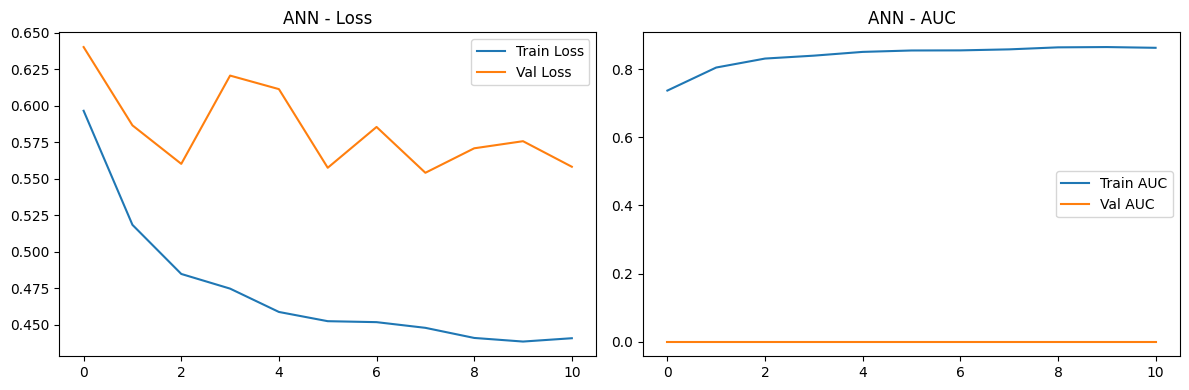

In [15]:
# training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ann_history.history['loss'], label='Train Loss')
axes[0].plot(ann_history.history['val_loss'], label='Val Loss')
axes[0].set_title('ANN - Loss')
axes[0].legend()

axes[1].plot(ann_history.history['auc'], label='Train AUC')
axes[1].plot(ann_history.history['val_auc'], label='Val AUC')
axes[1].set_title('ANN - AUC')
axes[1].legend()

plt.tight_layout()
plt.savefig('../Images/img2_ann_training.png', dpi=150, bbox_inches='tight')
plt.show()

63/63 [==============================] - 0s 2ms/step

=== ANN ===
ROC-AUC : 0.8410
Accuracy: 0.8045

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.90      0.85      0.87      1593
     Churned       0.52      0.62      0.57       407

    accuracy                           0.80      2000
   macro avg       0.71      0.74      0.72      2000
weighted avg       0.82      0.80      0.81      2000



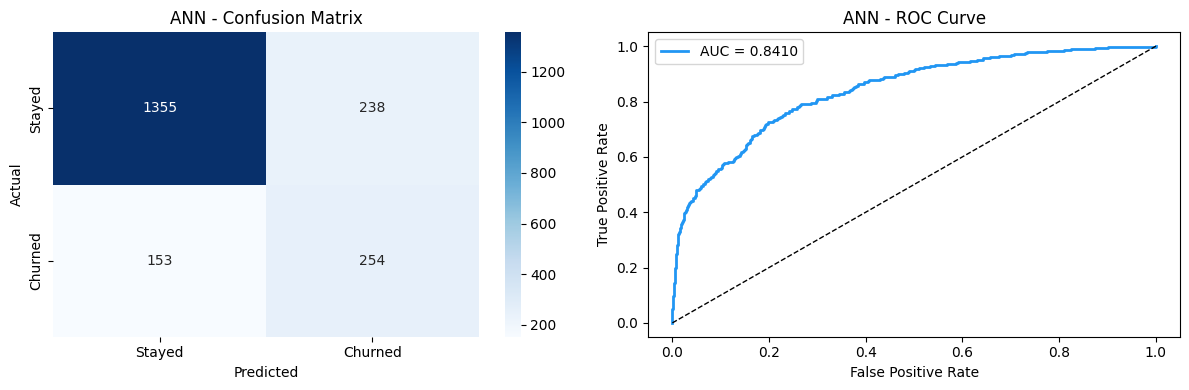

In [16]:
ann_proba = ann_model.predict(X_test_sc).flatten()
res_ann = evaluate_model('ANN', y_test, ann_proba)
all_results.append(res_ann)

In [ ]:
#start tabnet tomm

class TabNetLayer(layers.Layer):
    """
    Single step of TabNet attention mechanism.
    Each step decides which features to focus on.
    """
    def __init__(self, feature_dim, output_dim, num_steps=3, **kwargs):
        super().__init__(**kwargs)
        self.feature_dim = feature_dim
        self.output_dim  = output_dim
        self.num_steps   = num_steps

        # shared layers across steps
        self.shared_fc = layers.Dense(output_dim * 2, use_bias=False)
        self.shared_bn = layers.BatchNormalization()

        # step-specific layers
        self.step_fc = [layers.Dense(output_dim * 2, use_bias=False) for _ in range(num_steps)]
        self.step_bn = [layers.BatchNormalization() for _ in range(num_steps)]

        # attention transformer for each step
        self.attn_fc = [layers.Dense(feature_dim, use_bias=False) for _ in range(num_steps)]
        self.attn_bn = [layers.BatchNormalization() for _ in range(num_steps)]

        
        self.final_fc = layers.Dense(output_dim, activation='relu')

    def call(self, inputs, training=False):
        B = tf.shape(inputs)[0]
        prior_scales = tf.ones([B, self.feature_dim])
        aggregated   = tf.zeros([B, self.output_dim])
        importance   = tf.zeros([B, self.feature_dim])

        for step in range(self.num_steps):
       
            h = self.attn_fc[step](inputs)
            h = self.attn_bn[step](h, training=training)
            h = h * prior_scales
            alpha = tf.nn.softmax(h, axis=-1)          # feature weights
            prior_scales = prior_scales * (1.0 - alpha + 1e-6)
            importance   = importance + alpha

            masked = inputs * alpha

  
            x = self.shared_fc(masked)
            x = self.shared_bn(x, training=training)
            x = x + self.step_fc[step](masked)
            x = self.step_bn[step](x, training=training)
            x = tf.nn.relu(x)

            d = self.output_dim
            aggregated = aggregated + tf.nn.relu(x[:, :d]) * tf.nn.sigmoid(x[:, d:])

        out = self.final_fc(aggregated / self.num_steps)
        return out, importance / self.num_steps

    def get_config(self):
        config = super().get_config()
        config.update({
            'feature_dim': self.feature_dim,
            'output_dim' : self.output_dim,
            'num_steps'  : self.num_steps,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)




Model: "TabNet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 11)]              0         
                                                                 
 batch_normalization_2 (Batc  (None, 11)               44        
 hNormalization)                                                 
                                                                 
 tab_net_layer (TabNetLayer)  ((None, 64),             12335     
                              (None, 11))                        
                                                                 
 dense_12 (Dense)            (None, 32)                2080      
                                                                 
 dropout_3 (Dropout)         (None, 32)                0         
                                                                 
 dense_13 (Dense)            (None, 1)                 33   

In [ ]:
def build_tabnet(input_dim, output_dim=64, num_steps=3):
    inp    = layers.Input(shape=(input_dim,))
    bn_inp = layers.BatchNormalization()(inp)

    tabnet = TabNetLayer(input_dim, output_dim, num_steps)
    features, attention = tabnet(bn_inp)

    # final classification head
    x   = layers.Dense(32, activation='relu')(features)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inp, outputs=out, name='TabNet')
    return model


tabnet_model = build_tabnet(X_train_sm.shape[1])
tabnet_model.compile(
    optimizer=Adam(learning_rate=0.002),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
tabnet_model.summary()

In [18]:
early_stop2 = EarlyStopping(monitor='val_auc', patience=12, restore_best_weights=True,
                             mode='max', verbose=1)
reduce_lr2  = ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=6,
                                 mode='max', min_lr=1e-6, verbose=1)

tabnet_history = tabnet_model.fit(
    X_train_sm, y_train_sm,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stop2, reduce_lr2],
    verbose=1
)

Epoch 1/100
40/40 [==============================] - 4s 37ms/step - loss: 0.5802 - accuracy: 0.6982 - auc: 0.7344 - val_loss: 0.7554 - val_accuracy: 0.2473 - val_auc: 0.0000e+00 - lr: 0.0020
Epoch 2/100
40/40 [==============================] - 1s 20ms/step - loss: 0.4865 - accuracy: 0.7709 - auc: 0.8296 - val_loss: 0.7111 - val_accuracy: 0.4816 - val_auc: 0.0000e+00 - lr: 0.0020
Epoch 3/100
40/40 [==============================] - 1s 20ms/step - loss: 0.4454 - accuracy: 0.7916 - auc: 0.8589 - val_loss: 0.6469 - val_accuracy: 0.5946 - val_auc: 0.0000e+00 - lr: 0.0020
Epoch 4/100
40/40 [==============================] - 1s 22ms/step - loss: 0.4282 - accuracy: 0.7974 - auc: 0.8709 - val_loss: 0.6421 - val_accuracy: 0.6319 - val_auc: 0.0000e+00 - lr: 0.0020
Epoch 5/100
40/40 [==============================] - 1s 23ms/step - loss: 0.4205 - accuracy: 0.8074 - auc: 0.8766 - val_loss: 0.6258 - val_accuracy: 0.6315 - val_auc: 0.0000e+00 - lr: 0.0020
Epoch 6/100
40/40 [==========================

63/63 [==============================] - 1s 5ms/step

=== TabNet ===
ROC-AUC : 0.7870
Accuracy: 0.8210

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.83      0.98      0.90      1593
     Churned       0.71      0.21      0.32       407

    accuracy                           0.82      2000
   macro avg       0.77      0.59      0.61      2000
weighted avg       0.80      0.82      0.78      2000



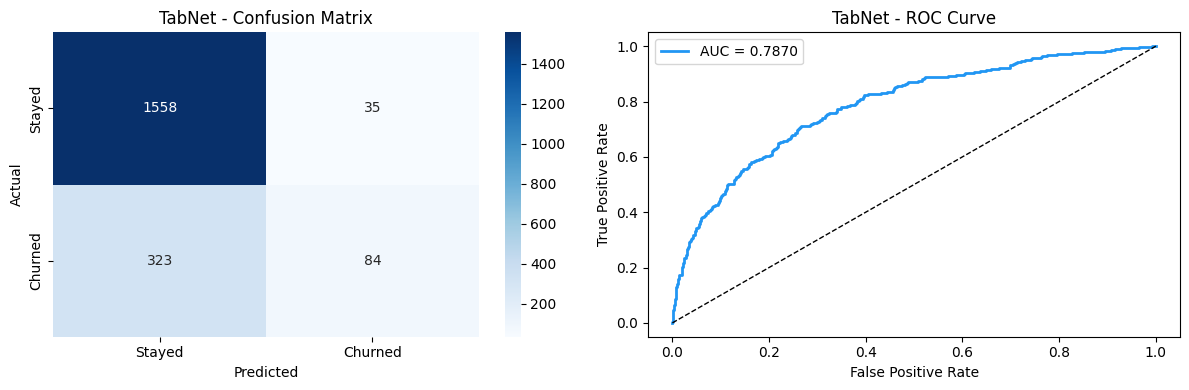

In [19]:
tabnet_proba = tabnet_model.predict(X_test_sc).flatten()
res_tabnet   = evaluate_model('TabNet', y_test, tabnet_proba)
all_results.append(res_tabnet)

In [ ]:
class FeatureTokenizer(layers.Layer):

    def __init__(self, num_features, d_token, **kwargs):
        super().__init__(**kwargs)
        self.num_features = num_features
        self.d_token      = d_token

    def build(self, input_shape):
        self.W = self.add_weight(
            name='W', shape=(self.num_features, self.d_token),
            initializer='glorot_uniform', trainable=True
        )
        self.b = self.add_weight(
            name='b', shape=(self.num_features, self.d_token),
            initializer='zeros', trainable=True
        )
        super().build(input_shape)

    def call(self, x):
        # x: (batch, num_features)
        # expand to (batch, num_features, 1) then multiply by W
        x = tf.expand_dims(x, axis=-1)                                     # (B, F, 1)
        tokens = x * self.W[tf.newaxis, :, :] + self.b[tf.newaxis, :, :]  # (B, F, d)
        return tokens

    def get_config(self):
        config = super().get_config()
        config.update({
            'num_features': self.num_features,
            'd_token'     : self.d_token,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)


def build_ft_transformer(num_features, d_token=32, num_heads=4, num_blocks=2, ffn_dim=64):
    inp    = layers.Input(shape=(num_features,))
    tokens = FeatureTokenizer(num_features, d_token)(inp)   # (B, F, d)

    for _ in range(num_blocks):
  
        attn_out = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=d_token // num_heads
        )(tokens, tokens)
        tokens = layers.LayerNormalization()(tokens + attn_out)

        ffn = layers.Dense(ffn_dim, activation='relu')(tokens)
        ffn = layers.Dense(d_token)(ffn)
        tokens = layers.LayerNormalization()(tokens + ffn)


    pooled = layers.GlobalAveragePooling1D()(tokens)

    x   = layers.Dense(32, activation='relu')(pooled)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inp, outputs=out, name='FT_Transformer')
    return model


ft_model = build_ft_transformer(X_train_sm.shape[1])
ft_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
ft_model.summary()

Model: "FT_Transformer"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 11)]         0           []                               
                                                                                                  
 feature_tokenizer (FeatureToke  (None, 11, 32)      704         ['input_3[0][0]']                
 nizer)                                                                                           
                                                                                                  
 multi_head_attention (MultiHea  (None, 11, 32)      4224        ['feature_tokenizer[0][0]',      
 dAttention)                                                      'feature_tokenizer[0][0]']      
                                                                                     

In [ ]:
early_stop3 = EarlyStopping(monitor='val_auc', patience=12, restore_best_weights=True,
                             mode='max', verbose=1)
reduce_lr3  = ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=6,
                                 mode='max', min_lr=1e-6, verbose=1)


In [ ]:

ft_history = ft_model.fit(
    X_train_sm, y_train_sm,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop3, reduce_lr3],
    verbose=1
)

Epoch 1/100
160/160 [==============================] - 9s 21ms/step - loss: 0.5106 - accuracy: 0.7558 - auc: 0.8095 - val_loss: 0.5122 - val_accuracy: 0.7606 - val_auc: 0.0000e+00 - lr: 0.0010
Epoch 2/100
160/160 [==============================] - 3s 17ms/step - loss: 0.4454 - accuracy: 0.7936 - auc: 0.8597 - val_loss: 0.6068 - val_accuracy: 0.6841 - val_auc: 0.0000e+00 - lr: 0.0010
Epoch 3/100
160/160 [==============================] - 3s 17ms/step - loss: 0.4383 - accuracy: 0.7990 - auc: 0.8644 - val_loss: 0.5627 - val_accuracy: 0.7068 - val_auc: 0.0000e+00 - lr: 0.0010
Epoch 4/100
160/160 [==============================] - 3s 18ms/step - loss: 0.4204 - accuracy: 0.8025 - auc: 0.8763 - val_loss: 0.7024 - val_accuracy: 0.6303 - val_auc: 0.0000e+00 - lr: 0.0010
Epoch 5/100
160/160 [==============================] - 3s 18ms/step - loss: 0.4160 - accuracy: 0.8072 - auc: 0.8796 - val_loss: 0.7242 - val_accuracy: 0.6075 - val_auc: 0.0000e+00 - lr: 0.0010
Epoch 6/100
160/160 [==============

63/63 [==============================] - 1s 7ms/step

=== FT-Transformer ===
ROC-AUC : 0.8519
Accuracy: 0.7855

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.92      0.80      0.86      1593
     Churned       0.48      0.74      0.58       407

    accuracy                           0.79      2000
   macro avg       0.70      0.77      0.72      2000
weighted avg       0.83      0.79      0.80      2000



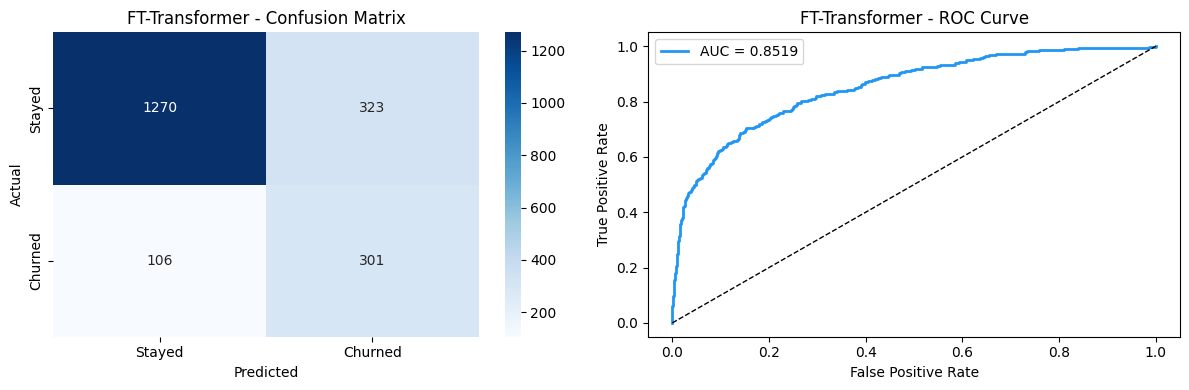

In [22]:
ft_proba = ft_model.predict(X_test_sc).flatten()
res_ft   = evaluate_model('FT-Transformer', y_test, ft_proba)
all_results.append(res_ft)

In [ ]:
def build_autoencoder(input_dim, encoding_dim=16):
    
    inp = layers.Input(shape=(input_dim,), name='ae_input')
    x   = layers.Dense(64, activation='relu')(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.2)(x)
    x   = layers.Dense(32, activation='relu')(x)
    encoded = layers.Dense(encoding_dim, activation='relu', name='bottleneck')(x)

    x   = layers.Dense(32, activation='relu')(encoded)
    x   = layers.Dense(64, activation='relu')(x)
    decoded = layers.Dense(input_dim, activation='linear', name='reconstruction')(x)

    autoencoder = Model(inputs=inp, outputs=decoded, name='Autoencoder')
    encoder     = Model(inputs=inp, outputs=encoded, name='Encoder')

    return autoencoder, encoder


Model: "Autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 ae_input (InputLayer)       [(None, 11)]              0         
                                                                 
 dense_20 (Dense)            (None, 64)                768       
                                                                 
 batch_normalization_10 (Bat  (None, 64)               256       
 chNormalization)                                                
                                                                 
 dropout_5 (Dropout)         (None, 64)                0         
                                                                 
 dense_21 (Dense)            (None, 32)                2080      
                                                                 
 bottleneck (Dense)          (None, 16)                528       
                                                       

In [ ]:
#model summary
ae_model, enc_model = build_autoencoder(X_train_sm.shape[1])
ae_model.compile(optimizer=Adam(0.001), loss='mse')
ae_model.summary()

In [ ]:

ae_early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

ae_history = ae_model.fit(
    X_train_sm, X_train_sm,     
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[ae_early],
    verbose=1
)
print('Autoencoder training done!')

Epoch 1/100
160/160 [==============================] - 2s 8ms/step - loss: 0.6452 - val_loss: 0.4070
Epoch 2/100
160/160 [==============================] - 1s 7ms/step - loss: 0.2705 - val_loss: 0.1447
Epoch 3/100
160/160 [==============================] - 1s 7ms/step - loss: 0.1774 - val_loss: 0.0784
Epoch 4/100
160/160 [==============================] - 1s 6ms/step - loss: 0.1351 - val_loss: 0.0434
Epoch 5/100
160/160 [==============================] - 1s 6ms/step - loss: 0.1163 - val_loss: 0.0424
Epoch 6/100
160/160 [==============================] - 1s 7ms/step - loss: 0.1066 - val_loss: 0.0364
Epoch 7/100
160/160 [==============================] - 1s 6ms/step - loss: 0.1000 - val_loss: 0.0303
Epoch 8/100
160/160 [==============================] - 1s 7ms/step - loss: 0.0954 - val_loss: 0.0289
Epoch 9/100
160/160 [==============================] - 1s 7ms/step - loss: 0.0873 - val_loss: 0.0328
Epoch 10/100
160/160 [==============================] - 1s 7ms/step - loss: 0.0810 - val_lo

In [ ]:

X_train_enc = enc_model.predict(X_train_sm)
X_test_enc  = enc_model.predict(X_test_sc)

print('Encoded train shape:', X_train_enc.shape)
print('Encoded test shape :', X_test_enc.shape)

63/63 [==============================] - 0s 1ms/step
Encoded train shape: (12740, 16)
Encoded test shape : (2000, 16)


In [ ]:
# now train a classifier tomm
def build_ae_classifier(encoding_dim):
    inp = layers.Input(shape=(encoding_dim,))
    x   = layers.Dense(32, activation='relu')(inp)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(16, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return Model(inp, out, name='AE_Classifier')


ae_clf = build_ae_classifier(X_train_enc.shape[1])
ae_clf.compile(
    optimizer=Adam(0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)


In [ ]:

clf_early = EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True,
                           mode='max', verbose=1)

ae_clf.fit(
    X_train_enc, y_train_sm,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[clf_early],
    verbose=1
)

Epoch 1/100
319/319 [==============================] - 2s 6ms/step - loss: 0.6466 - accuracy: 0.6316 - auc: 0.6295 - val_loss: 0.6628 - val_accuracy: 0.6389 - val_auc: 0.0000e+00
Epoch 2/100
319/319 [==============================] - 2s 6ms/step - loss: 0.5699 - accuracy: 0.7087 - auc: 0.7469 - val_loss: 0.8158 - val_accuracy: 0.5000 - val_auc: 0.0000e+00
Epoch 3/100
319/319 [==============================] - 2s 7ms/step - loss: 0.5404 - accuracy: 0.7294 - auc: 0.7794 - val_loss: 0.7587 - val_accuracy: 0.5714 - val_auc: 0.0000e+00
Epoch 4/100
319/319 [==============================] - 2s 6ms/step - loss: 0.5179 - accuracy: 0.7450 - auc: 0.8023 - val_loss: 0.8412 - val_accuracy: 0.5122 - val_auc: 0.0000e+00
Epoch 5/100
319/319 [==============================] - 2s 6ms/step - loss: 0.5007 - accuracy: 0.7590 - auc: 0.8167 - val_loss: 0.7103 - val_accuracy: 0.6205 - val_auc: 0.0000e+00
Epoch 6/100
319/319 [==============================] - 2s 6ms/step - loss: 0.4843 - accuracy: 0.7725 - au

63/63 [==============================] - 0s 2ms/step

=== Autoencoder + Classifier ===
ROC-AUC : 0.7502
Accuracy: 0.7270

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.76      0.82      1593
     Churned       0.39      0.59      0.47       407

    accuracy                           0.73      2000
   macro avg       0.63      0.68      0.64      2000
weighted avg       0.78      0.73      0.75      2000



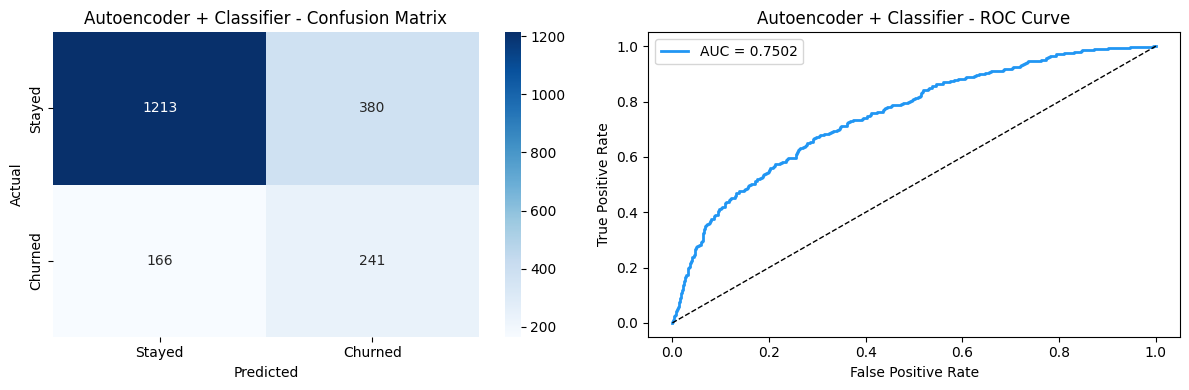

In [27]:
ae_proba = ae_clf.predict(X_test_enc).flatten()
res_ae   = evaluate_model('Autoencoder + Classifier', y_test, ae_proba)
all_results.append(res_ae)

In [28]:
# comparison table
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('roc_auc', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

                   model  roc_auc  accuracy
          FT-Transformer 0.851887    0.7855
                     ANN 0.841004    0.8045
                  TabNet 0.787046    0.8210
Autoencoder + Classifier 0.750243    0.7270


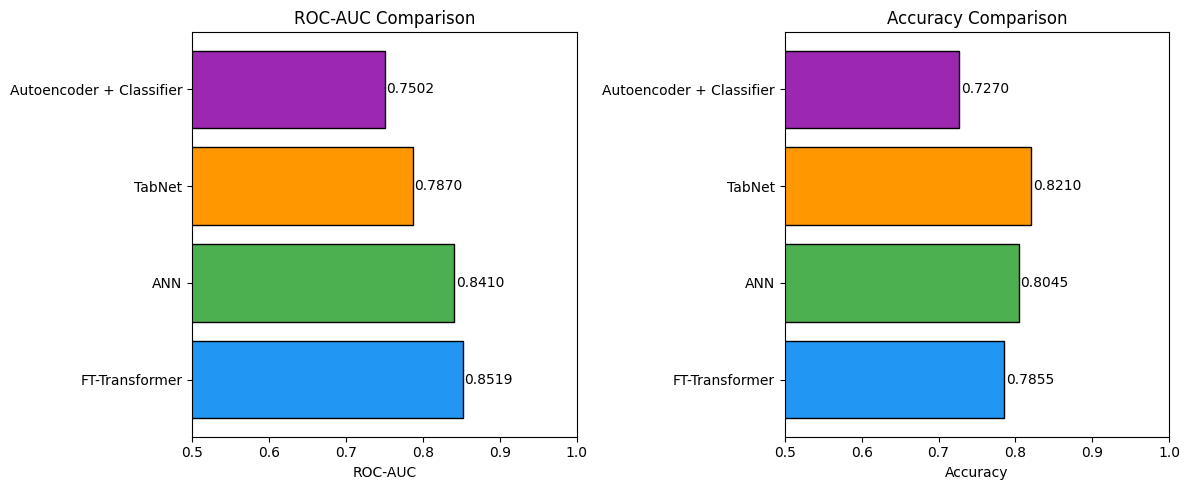

In [29]:
# bar plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

axes[0].barh(results_df['model'], results_df['roc_auc'],
             color=colors[:len(results_df)], edgecolor='black')
axes[0].set_title('ROC-AUC Comparison')
axes[0].set_xlabel('ROC-AUC')
axes[0].set_xlim(0.5, 1.0)
for i, v in enumerate(results_df['roc_auc']):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center')

axes[1].barh(results_df['model'], results_df['accuracy'],
             color=colors[:len(results_df)], edgecolor='black')
axes[1].set_title('Accuracy Comparison')
axes[1].set_xlabel('Accuracy')
axes[1].set_xlim(0.5, 1.0)
for i, v in enumerate(results_df['accuracy']):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.savefig('../Images/img3_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

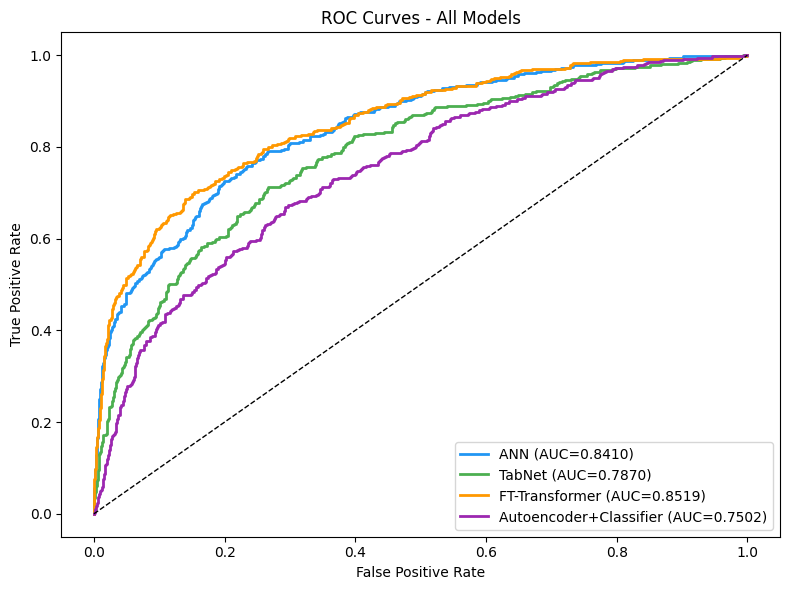

In [30]:
# overlay ROC curves
models_dict = {
    'ANN'                    : ann_proba,
    'TabNet'                 : tabnet_proba,
    'FT-Transformer'         : ft_proba,
    'Autoencoder+Classifier' : ae_proba
}

plt.figure(figsize=(8, 6))
for (name, proba), color in zip(models_dict.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../Images/img4_roc_all.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#shap implementation vuse bg sample (imp)
# finding best model
best_model_name = results_df.iloc[0]['model']
print(f'Best model: {best_model_name}')

# map to actual model and its test predictions
model_map = {
    'ANN'                    : (ann_model,    X_test_sc),
    'TabNet'                 : (tabnet_model, X_test_sc),
    'FT-Transformer'         : (ft_model,     X_test_sc),
    'Autoencoder + Classifier': (ae_clf,      X_test_enc)
}

best_model, best_X_test = model_map[best_model_name]

background = best_X_test[:100]
explainer  = shap.KernelExplainer(lambda x: best_model.predict(x).flatten(), background)
shap_vals  = explainer.shap_values(best_X_test[:200], nsamples=100)

print('SHAP computation done!')

Best model: FT-Transformer
4/4 [==============================] - 0s 6ms/step


  0%|          | 0/200 [00:00<?, ?it/s]

313/313 [==============================] - 2s 6ms/step
SHAP computation done!


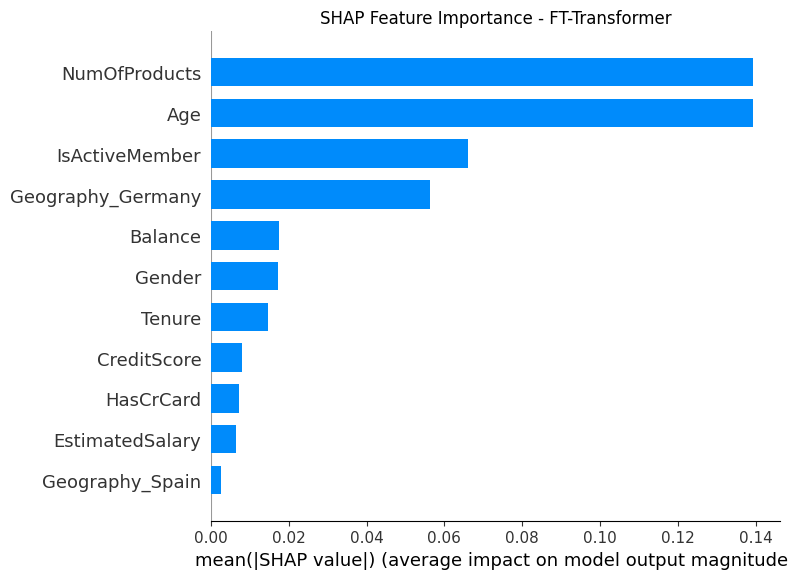

In [32]:
# use original feature names (AE uses encoded dims, others use real features)
if best_model_name == 'Autoencoder + Classifier':
    shap_feature_names = [f'enc_dim_{i}' for i in range(best_X_test.shape[1])]
else:
    shap_feature_names = feature_names

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, best_X_test[:200],
                  feature_names=shap_feature_names,
                  plot_type='bar', show=False)
plt.title(f'SHAP Feature Importance - {best_model_name}')
plt.tight_layout()
plt.savefig('../Images/img2_shap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import keras_tuner as kt

def build_tunable_ann(hp):
    inp    = layers.Input(shape=(X_train_sm.shape[1],))
    units1 = hp.Choice('units_1', [64, 128, 256])
    units2 = hp.Choice('units_2', [32, 64, 128])
    drop   = hp.Float('dropout', 0.1, 0.5, step=0.1)
    lr     = hp.Choice('lr', [0.0001, 0.0005, 0.001, 0.005])
    x   = layers.Dense(units1, activation='relu')(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(drop)(x)
    x   = layers.Dense(units2, activation='relu')(x)
    x   = layers.Dropout(drop)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    model.compile(
        optimizer=Adam(lr),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    return model


In [ ]:
# hyperparameter search on ANN.

tuner = kt.RandomSearch(
    build_tunable_ann,
    objective=kt.Objective('val_auc', direction='max'),
    max_trials=10,
    directory='kt_dir',
    project_name='churn_hp'
)


Reloading Tuner from kt_dir\churn_hp\tuner0.json
Best hyperparameters:
  units_1 : 128
  units_2 : 64
  dropout : 0.1
  lr      : 0.0005


In [ ]:
tuner.search(
    X_train_sm, y_train_sm,
    epochs=30,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_auc', patience=5, mode='max')],
    verbose=0
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print('Best hyperparameters:')
print('  units_1 :', best_hp.get('units_1'))
print('  units_2 :', best_hp.get('units_2'))
print('  dropout :', best_hp.get('dropout'))
print('  lr      :', best_hp.get('lr'))

In [ ]:

#different keras and tensorflow version caused error

In [39]:
import pickle

os.makedirs('../Model/saved_models', exist_ok=True)

# save all model weights as numpy dicts
def save_weights_dict(model, path):
    weights = {i: w.numpy() for i, w in enumerate(model.weights)}
    with open(path, 'wb') as f:
        pickle.dump(weights, f)

save_weights_dict(tabnet_model, '../Model/saved_models/tabnet_weights.pkl')
save_weights_dict(ft_model,     '../Model/saved_models/ft_weights.pkl')

# normal ones still .h5
ann_model.save('../Model/saved_models/ann_model.h5')
ae_model.save('../Model/saved_models/autoencoder_model.h5')
ae_clf.save('../Model/saved_models/ae_classifier.h5')
enc_model.save('../Model/saved_models/encoder_model.h5')

joblib.dump(X_train_sm.shape[1],  '../Model/saved_models/input_dim.pkl')
joblib.dump(scaler,               '../Model/saved_models/scaler.pkl')
joblib.dump(feature_names,        '../Model/saved_models/feature_names.pkl')
results_df.to_csv('../Model/saved_models/model_results.csv', index=False)

print('Done!')

Done!
